# EE 587 Introduction to Robotics Homework #3

### instructor: Prof. Dr. Afşar SARANLI

### Çağdaş Güven - 2738938

video link : https://youtu.be/WdBShw3Zuqs

1. Suppose that $a = (1,-1,2)$ and that $R = R_{x,90}$. Show by direct calculation that you have $RS(a)R^T = S(Ra)$

Rotation Matrix $R_x(90^\circ)$ and Skew Symmetric Matrix $S_a$ For $a = (1,-1,2)$ :

![alt text](question_1/q1.1.png)

Calculating $RS(a)R_T$ : Substituting R and S(a) : 

![alt text](question_1/q1.2.png)

Ra = 

![alt text](question_1/q1.3.png)

Skew symmetric matrix of Ra :

![alt text](question_1/q1.4.png)

Then Calculation of $RS(a)R^T$ : 

![alt text](question_1/q1.5.png)



2. Given the Euler angle transformation $R = R_{z,\phi}R_{y,\theta}R_{x,\psi}$, show that $\frac{d}{dt}R = S(w) R$
Where 

$\omega = (c_{\psi}s_{\theta}\dot{\Phi}-s_{\psi}\dot{\theta})i + (s_{\psi}s_{\theta}\dot{\psi}+c_{\psi}\dot{\theta})j + (\dot{\psi}+ c_{\theta}\dot{\Phi})k$ 

(the components of i,j an k are respectively called *nutation,spin* and *precession*)

For given Euler rotation general formula first finding the rotation matrices: 

![alt text](question_2/q2.1.png)

Then we find derivation of R

Using the product rule: 

![alt text](question_2/q2.2.png)

Derivative of Each Component:

![alt text](question_2/q2.3.png)

Combining Angular Velocity Components:

![alt text](question_2/q2.4.png)

Skew-Symmetric Matrix for $w$:

![alt text](question_2/q2.5.png)

Relationship Between $\frac{dR}{dt}$ and $S(w)$:

$ \frac{dR}{dt} = S(w)R$

Where $S(w)$ encodes the contributions of $\dot{\phi}$, $\dot{\theta}$, and $\dot{\psi}$ into a single matrix.






3. Let $R_{k,\theta}$ be the rotation matrix corresponding to a rotation around an axis defined by the vector $k = (k_1,k_2,k_3)$ . Prove using the Rodrigues' Formula that we have 

$\frac{d}{d\theta}R_{k,\theta} = S(k)R_{k,\theta}$

Problem statement and Rodrigues' rotation formula:

![alt text](question_3/q3.1.png)

Derivative of $R_{k,\theta}$ with respect to $\theta$:

![alt text](question_3/q3.2.png)

Rewriting Using $R_{k,\theta}$:

![alt text](question_3/q3.3.png)

which simplifies to:

$\frac{dR_{k,\theta}}{d\theta}= S(k)R_{k,\theta}$


4. Two frames {0} and {1} are related by the Homogeneous transormation 

$$
H =
    \begin{bmatrix}
        0 & -1 & 0 & 1\\
        1 & 0 & 0 & -1\\
        0 & 0 & 1 & 0\\
        0 & 0 & 0 & 1
    \end{bmatrix}
$$

A particle has velocity $v_1(t) = (3,1,0)$ relative to frame {1}. Calculate the particle velocity relative to frame {0}?

![alt text](question_4/unnamed.png)

#### Programming:

5. In this question, you will implement a simple “Robot controller” by using the *forward kinematics* and *inverse velocity kinematics* of a planar RR manipulator. We know all the kinematics and velocity kinematics equations of this planar robot from lecture notes. You can use either Matlab or Python to implement this question

**a.**  Write code to “simulate” a Planar RR robot with link lengths 𝑙1 =3 and 𝑙2 =
2 units. Define the angular ranges for the joints as 𝜃1 ={−90°,90°} and 𝜃2 =
{−170°,170°}. For any given pair of joint variables, you should be able to 
plot the robot on a plane (different colors for each link? Small circles for the 
joints? A fat point for the end effector?) 

**b.** Define two points in the robot workspace: The start point $p_s$ and goal point $p_g$ in the robot work-space. (You can later experiment with different start and end points) 

**c.** We would like to implement a discrete-time proportional position controller in the work-space that would take the robot from the initial point to the goal point. For this, you will periodically (at each time step): (1) calculate the position error, (2) define a required end-effector velocity vector (your controller), (3) transform this into required joint velocities, (4) execute the joint motion to determine the new end-effector position, (5) repeat the cycle.

**d.** Experiment with different sampling periods and controller Proportional Gains. 

**e.** Present your results in the report as “time snapshots” of the robot configuration and/or end effector positions. Also see (g) below. 

**f.** You should be able to detect and raise an alarm if a singularity is encountered during the control of the robot. 

**g.** Have a video recording (screen capture) of the execution of your controller for some example cases. Upload to YouTube as “unlisted” videos and share the link in your homework report. 

In [1]:
import numpy as np
import scipy.linalg
from scipy.linalg import expm
import roboticstoolbox as rtb
from roboticstoolbox import *
from roboticstoolbox import ERobot2, Link2
from spatialmath import *
from spatialmath.base import *
from spatialgeometry import Sphere, Box
from swift import Swift
from spatialmath import SE3, SE2
from roboticstoolbox import quintic, trapezoidal, mtraj, mstraj, xplot, ctraj
from mpl_toolkits.mplot3d import Axes3D
from roboticstoolbox.backends.PyPlot import PyPlot2, RobotPlot2
import math
import time
from math import pi
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.widgets import Slider
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle, Circle
np.set_printoptions(linewidth=100, formatter={'float': lambda x: f"{x:8.4g}" if abs(x) > 1e-10 else f"{0:8.4g}"})

%matplotlib widget

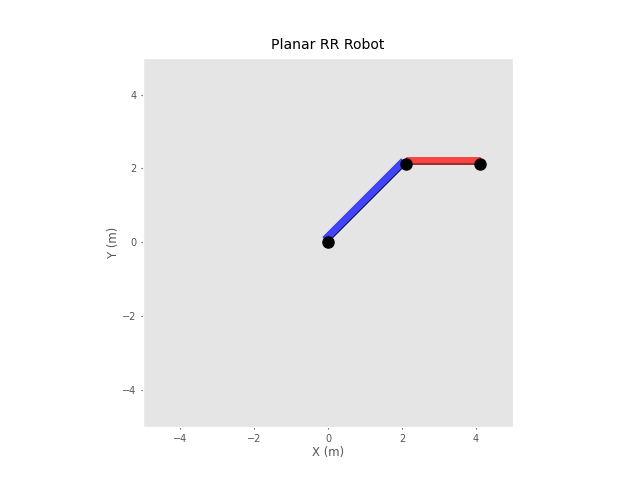

In [2]:
# Define link lengths
l1 = 3  # Length of link1
l2 = 2  # Length of link2

# Robot simulation function
def plot_robot(q, l1, l2, ax):
    """
    Plot the planar RR robot in a given configuration.
    """
    # Forward kinematics
    theta1, theta2 = q
    x1, y1 = l1 * np.cos(theta1), l1 * np.sin(theta1)  # End of link1
    x2, y2 = x1 + l2 * np.cos(theta1 + theta2), y1 + l2 * np.sin(theta1 + theta2)  # End of link2

    # Clear the axis
    ax.clear()
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.grid()

    # Plot link1 (blue rectangle)
    ax.add_patch(Rectangle((0, 0), l1, 0.2, angle=np.degrees(theta1), color='blue', alpha=0.7))
    # Plot link2 (red rectangle)
    ax.add_patch(Rectangle((x1, y1), l2, 0.2, angle=np.degrees(theta1 + theta2), color='red', alpha=0.7))

    # Plot joints and end-effector
    ax.plot([0, x1, x2], [0, y1, y2], '-o', markersize=8, color='black')
    ax.add_patch(Circle((x2, y2), radius=0.1, color='orange'))  # End-effector
    ax.set_title("Planar RR Robot")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")

# Test the robot plot
fig, ax = plt.subplots()
q_test = [np.deg2rad(45), np.deg2rad(-45)]  # Joint angles in radians
plot_robot(q_test, l1, l2, ax)
plt.show()


In [3]:
# Start and goal points in the workspace
p_s = np.array([3, 2])  # Start point
p_g = np.array([0, 5])  # Goal point

# Print workspace points
print("Start Point (p_s):", p_s)
print("Goal Point (p_g):", p_g)

Start Point (p_s): [3 2]
Goal Point (p_g): [0 5]


In [4]:
def proportional_controller(l1, l2, p_s, p_g, Kp=1.0, dt=0.1, max_steps=100):
    """
    Proportional position controller for a planar RR robot.
    """
    def inverse_kinematics(x, y, l1, l2):
        c2 = (x**2 + y**2 - l1**2 - l2**2) / (2 * l1 * l2)
        if abs(c2) > 1:
            raise ValueError("Target point is outside the workspace!")
        s2 = np.sqrt(1 - c2**2)
        theta2 = np.arctan2(s2, c2)
        theta1 = np.arctan2(y, x) - np.arctan2(l2 * s2, l1 + l2 * c2)
        return [theta1, theta2]

    # Initial configuration
    q = inverse_kinematics(p_s[0], p_s[1], l1, l2)

    # Store trajectory
    trajectory = [list(q)]  # Ensure the trajectory stores lists

    for step in range(max_steps):
        # Forward kinematics to compute current end-effector position
        theta1, theta2 = q
        x_current = l1 * np.cos(theta1) + l2 * np.cos(theta1 + theta2)
        y_current = l1 * np.sin(theta1) + l2 * np.sin(theta1 + theta2)
        p_current = np.array([x_current, y_current])

        # Calculate position error
        error = p_g - p_current

        # Check for convergence
        if np.linalg.norm(error) < 1e-2:
            print(f"Goal reached in {step} steps!")
            break

        # Compute end-effector velocity
        v = Kp * error

        # Compute Jacobian
        J = np.array([
            [-l1 * np.sin(theta1) - l2 * np.sin(theta1 + theta2), -l2 * np.sin(theta1 + theta2)],
            [l1 * np.cos(theta1) + l2 * np.cos(theta1 + theta2),  l2 * np.cos(theta1 + theta2)]
        ])
        J_inv = np.linalg.pinv(J)  # Pseudo-inverse for safety

        # Compute joint velocities
        q_dot = J_inv @ v

        # Update joint positions
        q = q + q_dot * dt
        trajectory.append(list(q))  # Append the current joint configuration as a list

    return trajectory

def is_singular(J):
    """
    Detect singular configurations based on Jacobian condition number.
    """
    max_steps = 250
    cond = np.linalg.cond(J)
    return cond > (max_steps-1)  # Example threshold for singularity




Goal reached in 119 steps!


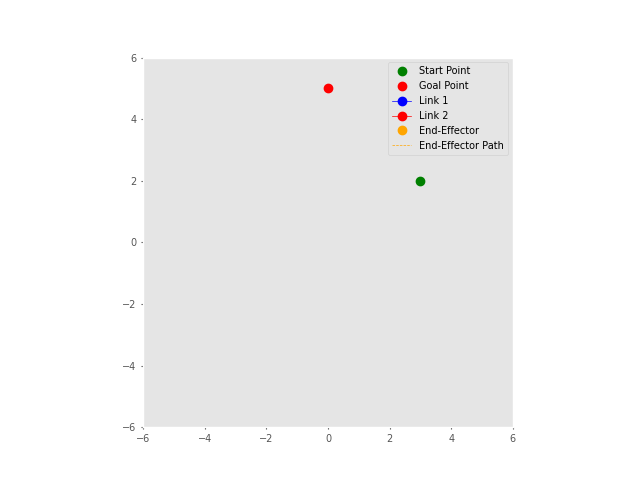

In [5]:
trajectory = proportional_controller(l1, l2, p_s, p_g, Kp=0.5, dt=0.1, max_steps=250)
# Initialize the figure and axes
fig, ax = plt.subplots()
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect('equal')
ax.grid()

ax.plot(p_s[0], p_s[1], 'go', label='Start Point')  # Start point (green circle)
ax.plot(p_g[0], p_g[1], 'ro', label='Goal Point')  # Goal point (red circle)

# Add elements for the links and the end-effector
link1_line, = ax.plot([], [], '-o', color='blue', label='Link 1')  # Link 1
link2_line, = ax.plot([], [], '-o', color='red', label='Link 2')   # Link 2
end_effector_circle = ax.plot([], [], 'o', color='orange', label='End-Effector')[0]  # End-effector
time_text = ax.text(-4, 4.5, '', fontsize=12, color='black')  # Time annotation
singularity_text = ax.text(-4, 4.0, '', fontsize=12, color='red')  # Singularity warning

trace_x, trace_y = [], []  # To store the end-effector path
trace, = ax.plot([], [], '--', color='orange', label='End-Effector Path') # path for end effector



# Animation update function
def update_plot(frame):
    """
    Update the plot for the current frame of the animation.
    """
    # Extract joint angles for the current frame
    q = trajectory[frame]  # Get joint angles for the current frame
    theta1, theta2 = q

    # Forward kinematics
    x1, y1 = l1 * np.cos(theta1), l1 * np.sin(theta1)  # End of link1
    x2, y2 = x1 + l2 * np.cos(theta1 + theta2), y1 + l2 * np.sin(theta1 + theta2)  # End of link2

    # Compute the Jacobian
    J = np.array([
        [-l1 * np.sin(theta1) - l2 * np.sin(theta1 + theta2), -l2 * np.sin(theta1 + theta2)],
        [l1 * np.cos(theta1) + l2 * np.cos(theta1 + theta2),  l2 * np.cos(theta1 + theta2)]
    ])
    
    # Check for singularity
    if is_singular(J):
        end_effector_circle.set_color('purple')  # Highlight singularities with a purple end-effector
    else:
        end_effector_circle.set_color('orange')  # Reset to orange

    # Update link1
    link1_line.set_data([0, x1], [0, y1])  # Base to end of link1

    # Update link2
    link2_line.set_data([x1, x2], [y1, y2])  # End of link1 to end of link2

    # Update end-effector
    end_effector_circle.set_data([x2], [y2])  # Position of end-effector

    # Update time display
    simulation_time = frame * 0.1  # Assuming dt=0.1 for each frame
    time_text.set_text(f"Time: {simulation_time:.1f} s")

    # Update the trace
    trace_x.append(x2)
    trace_y.append(y2)
    trace.set_data(trace_x, trace_y)

    # Detect large jumps (singularity-like behavior)
    if frame > 0:
        prev_q = trajectory[frame - 1]
        diff = np.abs(np.array(q) - np.array(prev_q))
        threshold = np.deg2rad(20)  # 20 degrees in radians
        if np.any(diff > threshold):
            singularity_text.set_text(f"Warning: Singularity detected at {simulation_time:.1f} s")
            time.sleep(1)  # Resume animation after 1 seconds
        else:
            #time.sleep(1)  # Resume animation after 1 seconds
            singularity_text.set_text('')  # Clear the warning

# Create the animation
ani = FuncAnimation(fig, update_plot, frames=len(trajectory), interval=100, repeat=True)

plt.legend()
plt.show()

In [6]:
# Create sliders for Kp and dt
ax_kp = plt.axes([0.25, 0.01, 0.65, 0.03])  # Position of Kp slider
ax_dt = plt.axes([0.25, 0.05, 0.65, 0.03])  # Position of dt slider

slider_kp = Slider(ax_kp, 'Kp', 0.1, 2.0, valinit=0.5)
slider_dt = Slider(ax_dt, 'dt', 0.01, 0.2, valinit=0.1)

def update_controller(val):
    """
    Update the controller with new Kp and dt values from sliders.
    """
    global trajectory
    Kp = slider_kp.val
    dt = slider_dt.val
    trajectory = proportional_controller(l1, l2, p_s, p_g, Kp=Kp, dt=dt, max_steps=250)
    ani.event_source.stop()
    ani.event_source.start()

slider_kp.on_changed(update_controller)
slider_dt.on_changed(update_controller)

0

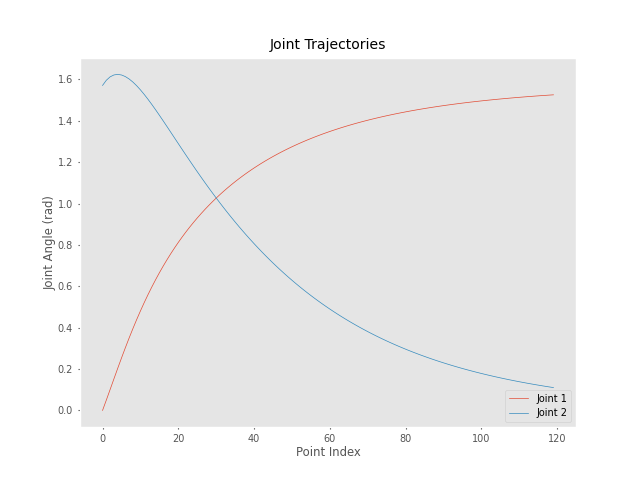

In [7]:
# Convert trajectory to radians for plotting
trajectory = np.array(trajectory)

# Plot joint trajectories
plt.figure()
for i in range(trajectory.shape[1]):
    plt.plot(trajectory[:, i], label=f'Joint {i + 1}')
plt.legend()
plt.xlabel('Point Index')
plt.ylabel('Joint Angle (rad)')
plt.title('Joint Trajectories')
plt.grid()
plt.show()

![alt text](reference.png)

This is our reference value Test.

![alt text](high_proportional.png)

With high proportional gain, motion is very fast, but it overshoots and oscillates.

![alt text](high_dt.png)

With high dt motion is very fast but it overshoots and oscillates.

![alt text](singularity_error.png)

And for singularity error we have a 1 sec pause for warning. It is possible to implement more secure mechanism in real scenario instead of just warning.

6. Review the P. Corke book and *Robotics Toolbox for Python* documentation to list (with short explanations) fundamental functions that calculate the *forward* and *inverse velocity kinematics* of robot arms as well as the *inverse position kinematics*. You may illustrate some examples that use these functions.

1. Forward Velocity Kinematics

This calculates the end-effector velocity (linear and angular) from the joint velocities using the Jacobian matrix.

Functions:

* jacob0(q):
    * Computes the Jacobian matrix relative to the **base frame**.
    * Inputs: Joint configuration $q$.
    * Outputs: Jacobian matrix $J_0$.

* jacobn(q):
    * Computes the Jacobian matrix relative to the end-effector frame.
    * Inputs: Joint configuration $q$.
    * Outputs: Jacobian matrix $J_n$​.

In [8]:
import numpy as np
from roboticstoolbox import models

# Load a Panda robot model
robot = models.DH.Panda()

# Joint configuration
q = [0, -np.pi/4, 0, -np.pi/2, 0, np.pi/3, 0]

# Compute the Jacobian relative to the base frame
J_base = robot.jacob0(q)

# Assume joint velocities (rad/s)
q_dot = np.array([0.1, 0.2, 0.1, 0.2, 0.1, 0.2, 0.1])

# Calculate end-effector velocity
v_ee = J_base @ q_dot
print("End-effector velocity:", v_ee)


End-effector velocity: [ 0.09237   0.0851  0.06089  0.02588     -0.2   0.1448]


2. Inverse Velocity Kinematics

This computes the joint velocities required to achieve a desired end-effector velocity.

Functions:

* np.linalg.pinv(J) @ v:
    * Uses the pseudo-inverse of the Jacobian matrix to solve for joint velocities $\dot{q}= J^+v$.

* jacob_dot(q, qd):
    * Computes the time derivative of the Jacobian matrix.
    * Useful for advanced control algorithms requiring second-order derivatives.

In [9]:
# Desired end-effector velocity
v_desired = np.array([0.1, 0.2, 0.0, 0.0, 0.0, 0.0])  # Linear and angular velocities

# Compute the pseudo-inverse of the Jacobian
J_inv = np.linalg.pinv(J_base)

# Compute joint velocities
q_dot_desired = J_inv @ v_desired
print("Required joint velocities:", q_dot_desired)


Required joint velocities: [-0.04709   0.1861    0.362  0.04198   0.2231   0.1442   0.3795]


3. Inverse Position Kinematics

This computes joint configurations required to achieve a specific end-effector pose.

Functions:

* ikine_LM(T):
    * Levenberg-Marquardt numerical inverse kinematics solver.
    * Inputs: Desired end-effector pose **T** (as an SE3 object).
    * Outputs: Joint configuration **q**.

* ikine_min(T):
    * Minimizes an objective function to solve for **q** (useful for constrained optimization problems).

In [10]:
from spatialmath import SE3

# Define the desired end-effector pose (as an SE3 object)
T_desired = SE3(0.5, 0.5, 0.5) * SE3.OA([1, 0, 0], [0, 1, 0])

# Solve inverse kinematics
ik_solution = robot.ikine_LM(T_desired)

# Extract joint configuration
q_solution = ik_solution.q
print("Joint configuration to achieve the desired pose:", q_solution)


Joint configuration to achieve the desired pose: [ -0.4645   0.3884    1.247   -1.841    1.611    2.397    -1.35]


**Key Function**

Function | Purpose | Inputs | Outputs
--- | --- | --- | ---
jacob0(q) | Jacobian in the base frame | joint configuration q | Jacobian matrix $J_0$
jacobn(q) | Jacobian in the end-effector frame | joint configuration q | Jacobian matrix $J_n$
np.linalg.pinv(J) | Solve inverse velocity kinematics | Jacobian matrix $J$, Velocity $v$ | Joint velocity $\dot{q}$
ikine_LM(T) | Solve inverse position kinematics | Desired pose **T** | Joint configuration q

In [11]:
# Load robot model Panda
robot = models.DH.Panda()

# Desired pose
T_goal = SE3(0.5, 0.3, 0.6) * SE3.OA([1, 0, 0], [0, 1, 0])

# Solve inverse kinematics for the desired pose
ik_result = robot.ikine_LM(T_goal)

# Compute forward velocity kinematics at the solved configuration
q_ik = ik_result.q
J = robot.jacob0(q_ik)

# Define a desired end-effector velocity
v_goal = np.array([0.1, 0.0, 0.0, 0.0, 0.0, 0.0])

# Compute joint velocities to achieve the desired velocity
q_dot = np.linalg.pinv(J) @ v_goal

print("Joint configuration (IK):", q_ik)
print("Required joint velocities:", q_dot)


Joint configuration (IK): [  -2.274   -2.135   0.6903   -2.057   -2.175    1.173   0.3252]
Required joint velocities: [ -0.1272   0.1296 -0.006739   0.3211 -0.03674  0.04238  -0.1695]
